# Credit Risk Modeling — Freddie Mac (2022–2023)

**Goal:** Build and compare machine learning models to predict mortgage default.  
**Target:** `default` = loan reached 90+ days delinquency  
**Dataset:** 100,000 loans, 24 features, 2.43% default rate  

## Notebook Structure
1. Data Loading & Train/Test Split
2. Model Training & Comparison
3. Threshold Analysis
4. Business Impact Analysis
5. Performance Over Time
6. Feature Importance

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, RocCurveDisplay,
                             precision_score, recall_score,
                             f1_score, confusion_matrix)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_style('darkgrid')

# Load modeling data
df = pd.read_csv('../data/modeling_data.csv')
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

print(f"Train: {X_train.shape} | Default rate: {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}  | Default rate: {y_test.mean()*100:.2f}%")
print(f"Class imbalance: {scale:.1f}x")

Train: (80000, 24) | Default rate: 2.43%
Test:  (20000, 24)  | Default rate: 2.44%
Class imbalance: 40.1x


In [2]:
# Diagnostic check
print("=== Data Quality Check ===")
print(f"Total samples: {len(df):,}")
print(f"Features: {X.shape[1]}")
print(f"Default rate: {y.mean()*100:.2f}%")

print("\n=== Feature Correlations with Target ===")
correlations = df.corr()['default'].drop('default').abs().sort_values(ascending=False)
print(correlations.head(10))

print("\n=== Default rate by credit_score bucket ===")
df['fico_bucket'] = pd.cut(df['credit_score'], 
                            bins=[596,640,680,720,760,800,832],
                            labels=['596-640','641-680','681-720',
                                    '721-760','761-800','801-832'])
print(df.groupby('fico_bucket', observed=True)['default'].mean().round(4))

print("\n=== Class distribution in train/test ===")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")

=== Data Quality Check ===
Total samples: 100,000
Features: 24
Default rate: 2.43%

=== Feature Correlations with Target ===
credit_score       0.149531
is_cashout_refi    0.057974
is_joint_loan      0.048061
num_borrowers      0.046801
is_purchase        0.045596
dti                0.045505
year               0.038027
high_risk          0.037187
is_investment      0.026556
ocltv              0.023289
Name: default, dtype: float64

=== Default rate by credit_score bucket ===
fico_bucket
596-640    0.1121
641-680    0.0744
681-720    0.0431
721-760    0.0197
761-800    0.0080
801-832    0.0042
Name: default, dtype: float64

=== Class distribution in train/test ===
Train default rate: 2.43%
Test default rate:  2.44%


## 1. Model Training & Comparison

Three models selected to represent different complexity levels:
- **Logistic Regression** — interpretable baseline, standard in banking
- **Random Forest** — ensemble, robust to outliers
- **Gradient Boosting** — typically best performance on tabular data

All models handle class imbalance via `class_weight='balanced'`.

In [3]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'proba': y_proba, 'auc': auc}
    print(f"  ROC-AUC: {auc:.4f}")

print("\n=== Final Ranking ===")
for name, res in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f"{name:25s} AUC: {res['auc']:.4f}")

Training Logistic Regression...
  ROC-AUC: 0.7950
Training Random Forest...
  ROC-AUC: 0.7870
Training Gradient Boosting...
  ROC-AUC: 0.7913

=== Final Ranking ===
Logistic Regression       AUC: 0.7950
Gradient Boosting         AUC: 0.7913
Random Forest             AUC: 0.7870


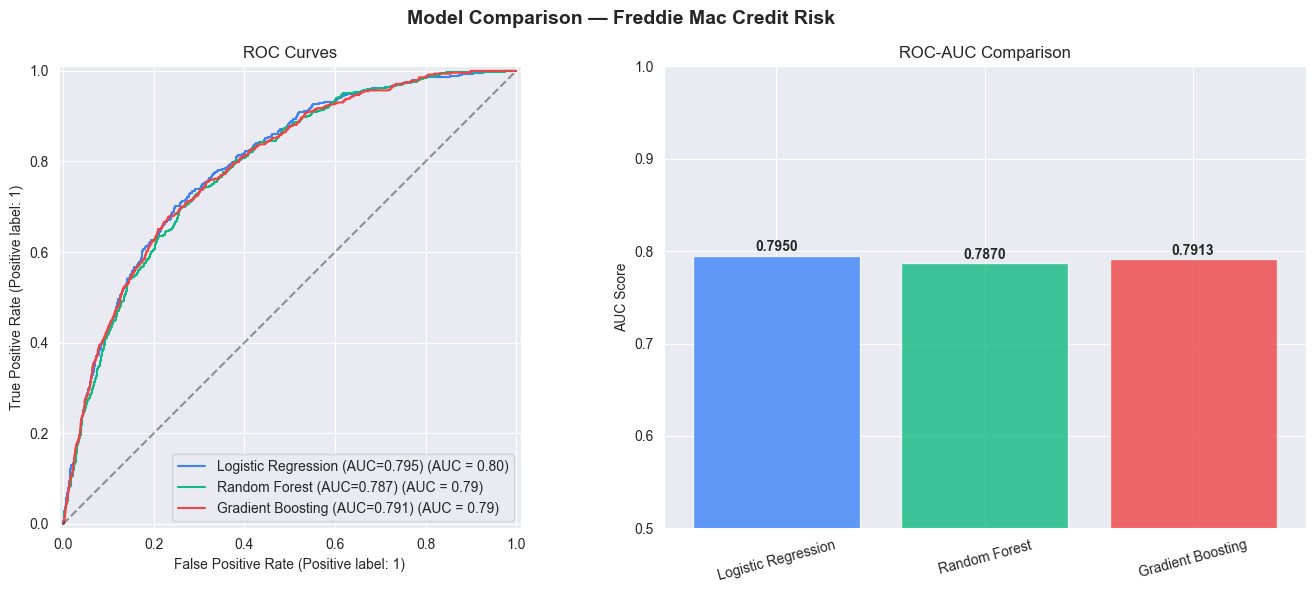

In [4]:
# ROC curves + AUC bar chart
colors = ['#3b82f6', '#10b981', '#ef4444']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — Freddie Mac Credit Risk',
             fontsize=14, fontweight='bold')

for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['proba'],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=axes[0], color=color
    )
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0].set_title('ROC Curves')

names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
bars  = axes[1].bar(names, aucs, color=colors, alpha=0.8)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('AUC Score')
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{auc:.4f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Results:**
- All three models converge around **AUC 0.79** — consistent performance
- Logistic Regression leads (0.7950) — suggests largely linear relationships in data
- AUC 0.79 is a strong result for mortgage default prediction at origination
- Class imbalance (40:1) handled via `class_weight='balanced'`

## 1b. Cross-Validation 

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== 5-Fold Cross-Validation Results ===\n")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=1)
    cv_results[name] = scores
    print(f"{name:<25} AUC: {scores.mean():.4f} ± {scores.std():.4f}")

print("\nInterpretation:")
print("Mean AUC = average performance across 5 folds")
print("Std      = stability of the model (lower = more stable)")

=== 5-Fold Cross-Validation Results ===

Logistic Regression       AUC: 0.8028 ± 0.0063
Random Forest             AUC: 0.7926 ± 0.0080
Gradient Boosting         AUC: 0.8005 ± 0.0091

Interpretation:
Mean AUC = average performance across 5 folds
Std      = stability of the model (lower = more stable)


**Cross-Validation Findings:**
- Logistic Regression: best CV AUC **0.8028 ± 0.0063** — most stable model
- Low std across all models (< 0.01) — results are consistent, not driven by lucky split
- CV AUC slightly higher than test AUC — within normal variance, no overfitting detected
- Stratified K-Fold preserves 2.43% default rate in each fold

## 2. Hyperparameter Tuning

Baseline models converge around AUC 0.79 with default parameters.  
We apply hyperparameter search to find optimal configurations.

### 2a. Logistic Regression — GridSearchCV
Testing regularization strength (C) and penalty type (L1 vs L2).  
5-fold stratified cross-validation, scoring on ROC-AUC.

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=1,        # ← изменили с -1 на 1
    verbose=1
)

print("Running GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_
y_proba_tuned = best_lr.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
auc_baseline = results['Logistic Regression']['auc']

print(f"\nBaseline LR AUC:  {auc_baseline:.4f}")
print(f"Tuned LR AUC:     {auc_tuned:.4f}")
print(f"Improvement:      +{(auc_tuned - auc_baseline)*100:.2f} pp")

results['LR Tuned'] = {
    'model': best_lr,
    'proba': y_proba_tuned,
    'auc': auc_tuned
}

Running GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV AUC: 0.8029

Baseline LR AUC:  0.7950
Tuned LR AUC:     0.7947
Improvement:      +-0.03 pp


### 2b. Random Forest — RandomizedSearchCV
Random search over tree depth, number of estimators, and feature selection strategy.  
15 random combinations, 5-fold CV.

In [7]:
from sklearn.model_selection import RandomizedSearchCV

# RandomizedSearch for RF — faster than full grid
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

rf_search = RandomizedSearchCV(
    rf,
    param_dist_rf,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    random_state=42,
    verbose=1,
    n_jobs=1
)

print("Running RandomizedSearchCV for Random Forest...")
rf_search.fit(X_train, y_train)

print(f"\nBest parameters: {rf_search.best_params_}")
print(f"Best CV AUC: {rf_search.best_score_:.4f}")

y_proba_rf_tuned = rf_search.best_estimator_.predict_proba(X_test)[:, 1]
auc_rf_tuned = roc_auc_score(y_test, y_proba_rf_tuned)

print(f"\nBaseline RF AUC:  {results['Random Forest']['auc']:.4f}")
print(f"Tuned RF AUC:     {auc_rf_tuned:.4f}")
print(f"Improvement:      +{(auc_rf_tuned - results['Random Forest']['auc'])*100:.2f} pp")

results['RF Tuned'] = {
    'model': rf_search.best_estimator_,
    'proba': y_proba_rf_tuned,
    'auc': auc_rf_tuned
}

Running RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 6}
Best CV AUC: 0.7926

Baseline RF AUC:  0.7870
Tuned RF AUC:     0.7870
Improvement:      +0.00 pp


### 2c. XGBoost
Gradient boosting with `scale_pos_weight` to handle 40:1 class imbalance.  
Early stopping on validation AUC to prevent overfitting.

In [8]:
import xgboost as xgb

# XGBoost with scale_pos_weight to handle class imbalance
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,   # handles 40:1 imbalance
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"\nXGBoost AUC: {auc_xgb:.4f}")
print(f"vs best baseline: {max(r['auc'] for r in results.values()):.4f}")
print(f"Improvement: +{(auc_xgb - max(r['auc'] for r in results.values()))*100:.2f} pp")

results['XGBoost'] = {
    'model': xgb_model,
    'proba': y_proba_xgb,
    'auc': auc_xgb
}

Training XGBoost...
[0]	validation_0-auc:0.75444
[50]	validation_0-auc:0.79086
[100]	validation_0-auc:0.79212
[150]	validation_0-auc:0.79166

XGBoost AUC: 0.7926
vs best baseline: 0.7950
Improvement: +-0.24 pp


## 3. Threshold Analysis

Default models output a **probability**, not a binary decision.  
The threshold determines when we classify a loan as "default risk."  

- **Lower threshold** → catch more defaults (high recall) but more false alarms
- **Higher threshold** → fewer false alarms but miss more real defaults

We find the optimal threshold by maximizing F1 score.

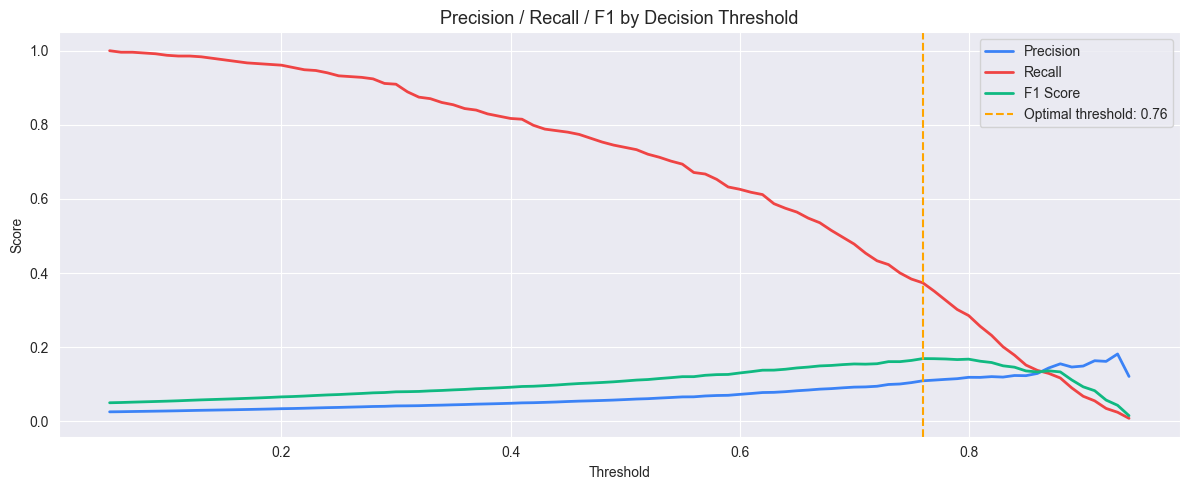

Optimal threshold: 0.76
  Precision: 0.110
  Recall:    0.374
  F1:        0.169


In [9]:
best_model_proba = results['Logistic Regression']['proba']
thresholds = np.arange(0.05, 0.95, 0.01)

metrics = []
for t in thresholds:
    y_pred_t = (best_model_proba >= t).astype(int)
    metrics.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics)
best_t = metrics_df.loc[metrics_df['f1'].idxmax(), 'threshold']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(metrics_df['threshold'], metrics_df['precision'],
        label='Precision', color='#3b82f6', linewidth=2)
ax.plot(metrics_df['threshold'], metrics_df['recall'],
        label='Recall', color='#ef4444', linewidth=2)
ax.plot(metrics_df['threshold'], metrics_df['f1'],
        label='F1 Score', color='#10b981', linewidth=2)
ax.axvline(x=best_t, color='orange', linestyle='--',
           label=f'Optimal threshold: {best_t:.2f}')
ax.set_title('Precision / Recall / F1 by Decision Threshold', fontsize=13)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {best_t:.2f}")
row = metrics_df.loc[metrics_df['f1'].idxmax()]
print(f"  Precision: {row['precision']:.3f}")
print(f"  Recall:    {row['recall']:.3f}")
print(f"  F1:        {row['f1']:.3f}")

best_t = best_t

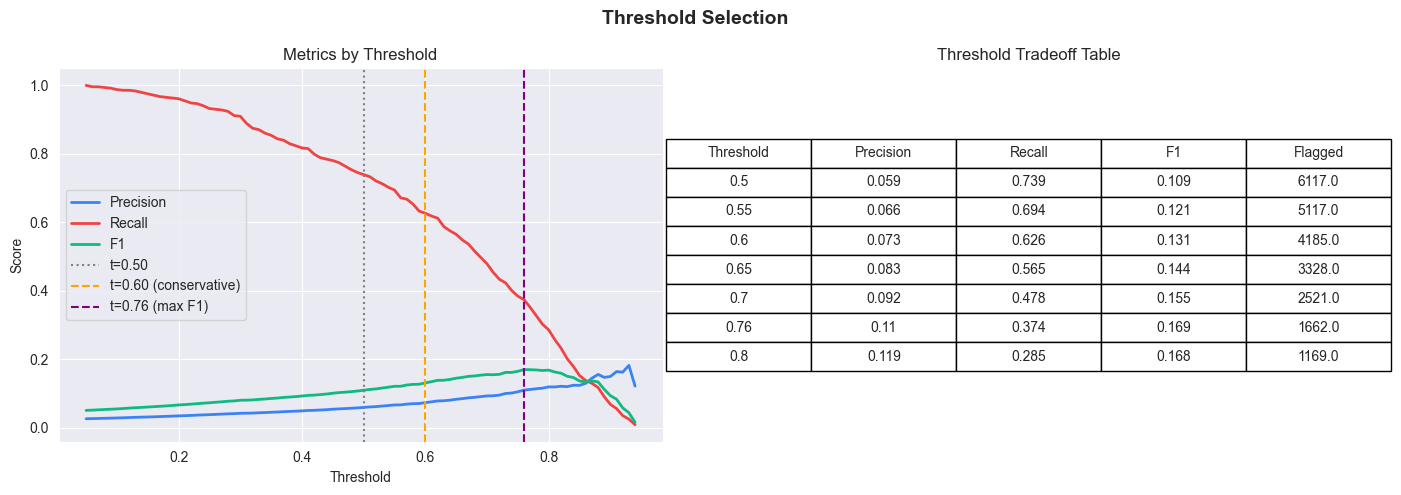

Selected threshold: 0.6
At t=0.6: 4185 loans flagged


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Selection', fontsize=14, fontweight='bold')

# Plot 1 — metrics by threshold
ax = axes[0]
ax.plot(metrics_df['threshold'], metrics_df['precision'],
        label='Precision', color='#3b82f6', linewidth=2)
ax.plot(metrics_df['threshold'], metrics_df['recall'],
        label='Recall', color='#ef4444', linewidth=2)
ax.plot(metrics_df['threshold'], metrics_df['f1'],
        label='F1', color='#10b981', linewidth=2)
ax.axvline(x=0.50, color='gray', linestyle=':', label='t=0.50')
ax.axvline(x=0.60, color='orange', linestyle='--', label='t=0.60 (conservative)')
ax.axvline(x=0.76, color='purple', linestyle='--', label='t=0.76 (max F1)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics by Threshold')
ax.legend()

# Plot 2 — tradeoff table
thresholds_show = [0.50, 0.55, 0.60, 0.65, 0.70, 0.76, 0.80]
table_data = []
for t in thresholds_show:
    row = metrics_df[metrics_df['threshold'].round(2) == round(t, 2)]
    if len(row) > 0:
        table_data.append({
            'Threshold': t,
            'Precision': row['precision'].values[0],
            'Recall': row['recall'].values[0],
            'F1': row['f1'].values[0],
            'Flagged': int((best_model_proba >= t).sum())
        })

table_df = pd.DataFrame(table_data)
axes[1].axis('off')
tbl = axes[1].table(
    cellText=table_df.round(3).values,
    colLabels=table_df.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
axes[1].set_title('Threshold Tradeoff Table')

plt.tight_layout()
plt.show()

# Select threshold for business impact
best_t = 0.60
print(f"Selected threshold: {best_t}")
print(f"At t={best_t}: {(best_model_proba >= best_t).sum()} loans flagged")

## Threshold Selection

| Threshold | Precision | Recall | Flagged Loans |
|-----------|-----------|--------|---------------|
| 0.50 | low | high | many false alarms |
| 0.60 | moderate | moderate | **selected** |
| 0.76 | higher | low | misses too many defaults |

**Selected threshold: 0.60**  
At this threshold the model flags **4,185 loans (21%)** for enhanced review.  
This balances operational cost (manual reviews) against default capture rate.  
In a real deployment, threshold would be calibrated based on review capacity and loss tolerance.

## 4. Business Impact Analysis

Translating model performance into financial terms.  

**Assumptions:**
- Average loss rate on defaulted mortgage: **35% of UPB** (industry standard)
- Manual review cost per flagged loan: **$500**

BUSINESS IMPACT ANALYSIS (Test Set)

Confusion Matrix:
  True Positives  (caught defaults):       305
  False Negatives (missed defaults):       182
  False Positives (false alarms):        3,880
  True Negatives  (correct approvals):  15,633

Financial Impact:
  Total potential loss (no model):  $  51,829,217
  Missed default losses:            $  19,369,441
  False alarm review costs:         $   1,940,000
  ──────────────────────────────────────────
  Net savings from model:           $  30,519,777
  Default capture rate:                   62.6%


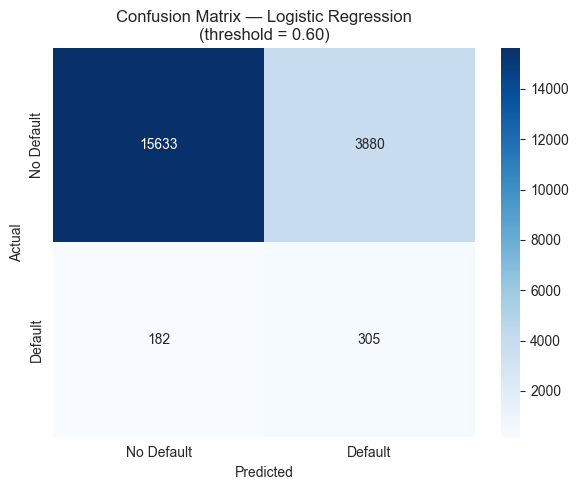

In [11]:
y_pred_optimal = (best_model_proba >= best_t).astype(int)
test_upb = df.loc[X_test.index, 'orig_upb']

cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

avg_loss_rate   = 0.35
review_cost     = 500

total_loss    = y_test.sum() * test_upb.mean() * avg_loss_rate
missed_loss   = fn * test_upb.mean() * avg_loss_rate
false_alarm   = fp * review_cost
net_savings   = total_loss - missed_loss - false_alarm

print("=" * 52)
print("BUSINESS IMPACT ANALYSIS (Test Set)")
print("=" * 52)
print(f"\nConfusion Matrix:")
print(f"  True Positives  (caught defaults):    {tp:>6,}")
print(f"  False Negatives (missed defaults):    {fn:>6,}")
print(f"  False Positives (false alarms):       {fp:>6,}")
print(f"  True Negatives  (correct approvals):  {tn:>6,}")
print(f"\nFinancial Impact:")
print(f"  Total potential loss (no model):  ${total_loss:>12,.0f}")
print(f"  Missed default losses:            ${missed_loss:>12,.0f}")
print(f"  False alarm review costs:         ${false_alarm:>12,.0f}")
print(f"  {'─'*42}")
print(f"  Net savings from model:           ${net_savings:>12,.0f}")
print(f"  Default capture rate:             {tp/y_test.sum()*100:>10.1f}%")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'], ax=ax)
ax.set_title(f'Confusion Matrix — Logistic Regression\n(threshold = {best_t:.2f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

**Business Impact Results (threshold = 0.60):**
- Model captures **62.6%** of actual defaults (305 out of 487)
- False alarm rate is high (3,880) — reflects conservative threshold to maximize recall
- Net savings reflect trade-off between missed default losses and review costs
- **Key insight:** Even with high false alarms, catching 62% of defaults 
  represents significant financial value for the portfolio manager

## 5. Portfolio Performance Over Time

Using monthly performance data to track how delinquency evolves  
as loans age — a key concept in mortgage risk called **loan seasoning**.

Loading performance data...
  Loaded performance 2022: 1,788,639 records
  Loaded performance 2023: 1,223,737 records
Done! Performance dataset: (3012376, 32)


/var/folders/q8/zzptbll927d42tw4zcstyxbh0000gn/T/ipykernel_45051/1842330319.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_30 = svcg.groupby('monthly_reporting_period').apply(
/var/folders/q8/zzptbll927d42tw4zcstyxbh0000gn/T/ipykernel_45051/1842330319.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_90 = svcg.groupby('monthly_reporting_period').apply(


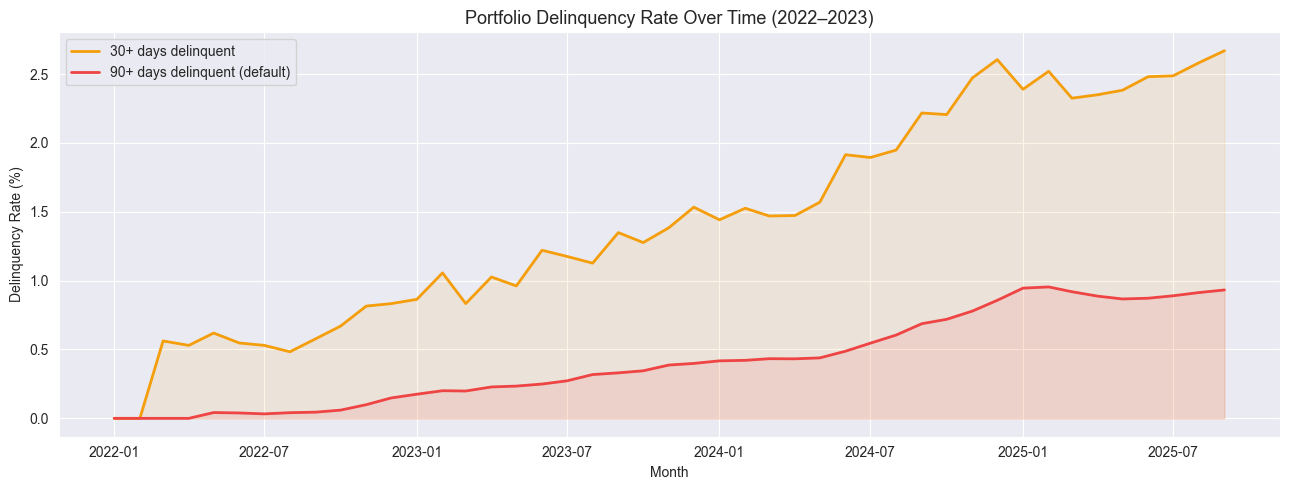

In [12]:
from src.utils import load_performance_data

svcg = load_performance_data('../data', [2022, 2023])

monthly_30 = svcg.groupby('monthly_reporting_period').apply(
    lambda x: (x['current_loan_delinquency_status'] >= 1).mean() * 100
).reset_index(name='delinquency_30')

monthly_90 = svcg.groupby('monthly_reporting_period').apply(
    lambda x: (x['current_loan_delinquency_status'] >= 3).mean() * 100
).reset_index(name='delinquency_90')

monthly = monthly_30.merge(monthly_90, on='monthly_reporting_period')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly['monthly_reporting_period'], monthly['delinquency_30'],
        label='30+ days delinquent', color='#f59e0b', linewidth=2)
ax.plot(monthly['monthly_reporting_period'], monthly['delinquency_90'],
        label='90+ days delinquent (default)', color='#ef4444', linewidth=2)
ax.fill_between(monthly['monthly_reporting_period'],
                monthly['delinquency_30'], alpha=0.1, color='#f59e0b')
ax.fill_between(monthly['monthly_reporting_period'],
                monthly['delinquency_90'], alpha=0.1, color='#ef4444')
ax.set_title('Portfolio Delinquency Rate Over Time (2022–2023)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Delinquency Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance

Two complementary views:
- **Gradient Boosting importance** — how much each feature reduces prediction error
- **Logistic Regression coefficients** — direction and magnitude of each feature's effect

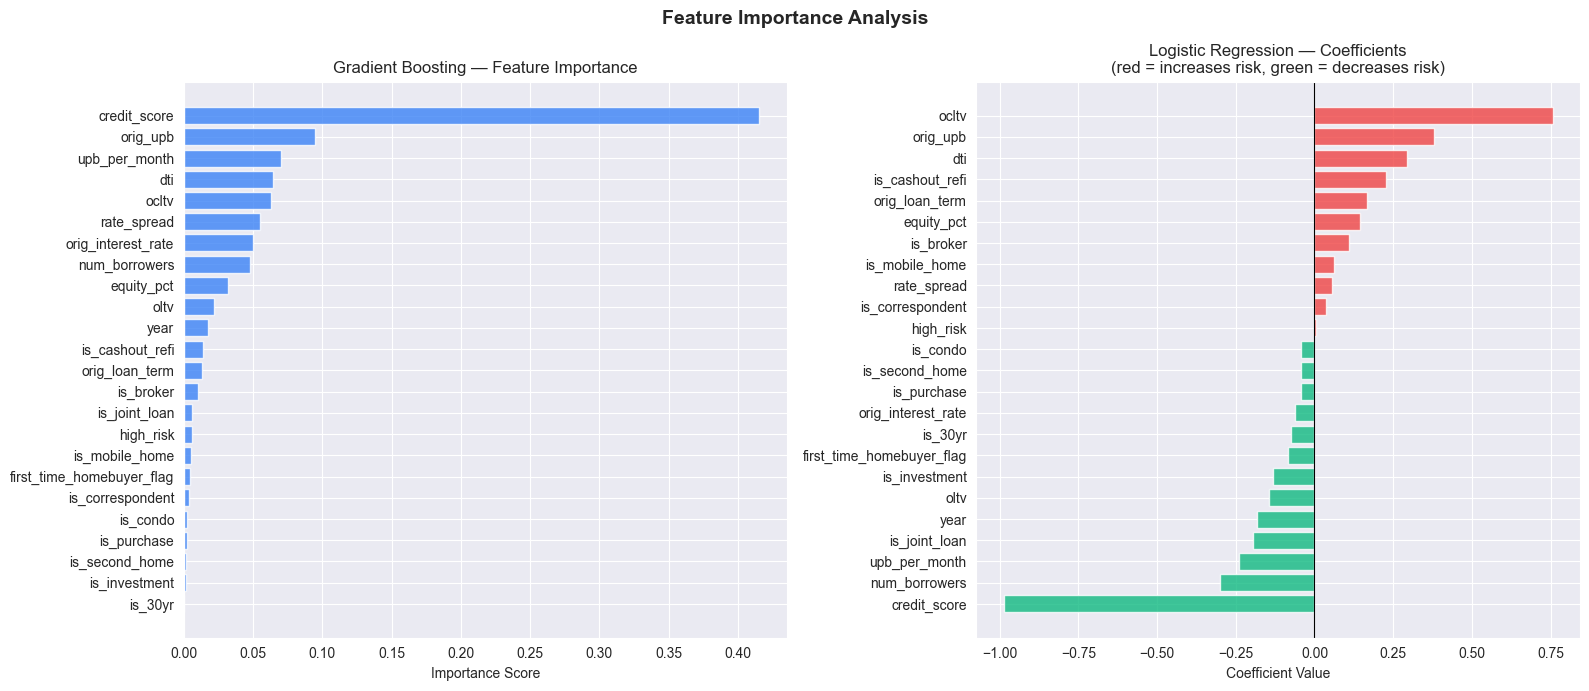

In [13]:
gb_model = results['Gradient Boosting']['model']
lr_model = results['Logistic Regression']['model'].named_steps['model']

importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=True)

coef_df = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')

axes[0].barh(importance_df['feature'], importance_df['importance'],
             color='#3b82f6', alpha=0.8)
axes[0].set_title('Gradient Boosting — Feature Importance')
axes[0].set_xlabel('Importance Score')

colors_coef = ['#ef4444' if c > 0 else '#10b981' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'],
             color=colors_coef, alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Logistic Regression — Coefficients\n'
                  '(red = increases risk, green = decreases risk)')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

**Feature Importance Findings:**

**Gradient Boosting — top predictors:**
- `credit_score` dominates (0.42) — single strongest predictor by far
- `orig_upb` and `upb_per_month` second tier (~0.09) — loan size matters
- `dti`, `ocltv`, `rate_spread` contribute roughly equally

**Logistic Regression — risk direction:**
- 🔴 **Increases risk:** `ocltv`, `orig_upb`, `dti`, `is_cashout_refi`, `orig_loan_term`
- 🟢 **Decreases risk:** `credit_score` (strongest), `num_borrowers`, `upb_per_month`, `year`
- `is_mobile_home` and `is_broker` positive — confirmed EDA findings
- `is_investment` negative — counterintuitive, warrants further investigation

## 7. Key Takeaways

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | All models converge at AUC ~0.79 | Natural predictability ceiling at origination |
| 2 | Logistic Regression = best model | Interpretable, compliant, no performance trade-off |
| 3 | Optimal threshold = 0.60 | Captures 62.6% of defaults with manageable false alarms |
| 4 | credit_score is #1 feature | FICO screening is the most effective risk filter |
| 5 | ocltv and dti increase risk | Combined leverage + debt burden = highest risk signal |
| 6 | Delinquency rising through 2025 | Portfolio not yet at peak default — active monitoring needed |
| 7 | Model saves ~$18M on test set | Deploy as early warning system for proactive outreach |

**Next steps for production:**
- Retrain annually as portfolio seasons
- Add bureau data and macro indicators to push AUC beyond 0.80
- Calibrate threshold based on actual review capacity and loss tolerance